In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
from time import time

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- IMPORT UNTUK BALANCING (IMBLEARN) ---
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
# ----------------------------------------

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

OUTPUT_DIR = "output_models"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
#HELPER FUNCTIONS & FEATURE ENGINEERING LENGKAP (41 FITUR)

def clean_numeric(value):
    if isinstance(value, (int, float, np.number)):
        return float(value)
    if not isinstance(value, str):
        return np.nan
    v = value.replace('Rp', '').replace('.', '').replace(',', '.').replace('"', '').strip()
    try:
        return float(v)
    except:
        return np.nan

def safe_divide(num, denom):
    return num / (denom + 1e-6)

def build_features(df):
    """Membangun 43 fitur: 41 fitur numerik + NAMA SKPD (encoded) + TAHUN"""
    cols = ['PAGU POKOK', 'PAGU PARSIAL', 'PAGU PERUBAHAN',
            'TARGET FISIK TW1', 'TARGET FISIK TW2', 'TARGET FISIK TW3', 'TARGET FISIK TW4',
            'TARGET KEUANGAN TW1', 'TARGET KEUANGAN TW2', 'TARGET KEUANGAN TW3', 'TARGET KEUANGAN TW4',
            'REALISASI FISIK TW1', 'REALISASI FISIK TW2', 'REALISASI FISIK TW3',
            'REALISASI KEUANGAN TW1', 'REALISASI KEUANGAN TW2', 'REALISASI KEUANGAN TW3']
    for c in cols:
        if c not in df.columns:
            df[c] = 0.0

    for tw in [1, 2, 3]:
        df[f'RASIO_FISIK_TW{tw}']       = safe_divide(df[f'REALISASI FISIK TW{tw}'], df[f'TARGET FISIK TW{tw}'])
        df[f'RASIO_KEU_TW{tw}']         = safe_divide(df[f'REALISASI KEUANGAN TW{tw}'], df[f'TARGET KEUANGAN TW{tw}'])
        df[f'GAP_FISIK_TW{tw}']         = df[f'TARGET FISIK TW{tw}'] - df[f'REALISASI FISIK TW{tw}']
        df[f'GAP_KEU_TW{tw}']           = df[f'TARGET KEUANGAN TW{tw}'] - df[f'REALISASI KEUANGAN TW{tw}']
        df[f'DEVIASI_FISIK_KEU_TW{tw}'] = (df[f'RASIO_FISIK_TW{tw}'] - df[f'RASIO_KEU_TW{tw}']).abs()

    df['TREN_FISIK_TW1_TW2'] = safe_divide(df['REALISASI FISIK TW2'] - df['REALISASI FISIK TW1'], df['REALISASI FISIK TW1'])
    df['TREN_FISIK_TW2_TW3'] = safe_divide(df['REALISASI FISIK TW3'] - df['REALISASI FISIK TW2'], df['REALISASI FISIK TW2'])
    df['TREN_FISIK_TW1_TW3'] = safe_divide(df['REALISASI FISIK TW3'] - df['REALISASI FISIK TW1'], df['REALISASI FISIK TW1'])

    df['TREN_KEU_TW1_TW2'] = safe_divide(df['REALISASI KEUANGAN TW2'] - df['REALISASI KEUANGAN TW1'], df['REALISASI KEUANGAN TW1'])
    df['TREN_KEU_TW2_TW3'] = safe_divide(df['REALISASI KEUANGAN TW3'] - df['REALISASI KEUANGAN TW2'], df['REALISASI KEUANGAN TW2'])
    df['TREN_KEU_TW1_TW3'] = safe_divide(df['REALISASI KEUANGAN TW3'] - df['REALISASI KEUANGAN TW1'], df['REALISASI KEUANGAN TW1'])

    df['PROYEKSI_FISIK_TW4']      = (df['REALISASI FISIK TW1'] + df['REALISASI FISIK TW2'] + df['REALISASI FISIK TW3']) / 3.0
    df['PROYEKSI_KEU_TW4']        = (df['REALISASI KEUANGAN TW1'] + df['REALISASI KEUANGAN TW2'] + df['REALISASI KEUANGAN TW3']) / 3.0
    df['GAP_PROYEKSI_TARGET']     = df['TARGET FISIK TW4'] - df['PROYEKSI_FISIK_TW4']
    df['GAP_PROYEKSI_KEU_TARGET'] = df['TARGET KEUANGAN TW4'] - df['PROYEKSI_KEU_TW4']
    df['KECEPATAN_FISIK']         = safe_divide(df['REALISASI FISIK TW3'] - df['REALISASI FISIK TW1'], 2.0)

    return df

def assign_optimal_cluster(pagu):
    if pagu <= 200_000_000:      return 'K1 (<=200jt)'
    elif pagu <= 1_000_000_000:  return 'K2 (200jt-1M)'
    elif pagu <= 5_000_000_000:  return 'K3 (1M-5M)'
    elif pagu <= 15_000_000_000: return 'K4 (5M-15M)'
    else:                        return 'K5 (>15M)'

In [ ]:
#LOAD DATA & PREPROCESSING

print("\n[1/9] Memuat Dataset Terpisah...")
df_risk_raw = pd.read_excel('DATASET LABEL BERISIKO.xlsx')
df_safe_raw = pd.read_excel('DATA LABEL TIDAK BERISIKO.xlsx')

df_risk_raw['LABEL_BIN'] = 'BERISIKO'
df_safe_raw['LABEL_BIN'] = 'TIDAK BERISIKO'

original_risk_count = len(df_risk_raw)
original_safe_count = len(df_safe_raw)

for d in [df_risk_raw, df_safe_raw]:
    if 'NAMA SKPD' not in d.columns:
        d['NAMA SKPD'] = 'UNKNOWN'
    if 'TAHUN' not in d.columns:
        d['TAHUN'] = 0

    non_numeric_cols = ['NAMA SKPD', 'NAMA PROGRAM', 'LABEL RISIKO', 'LABEL_BIN']
    num_cols = [c for c in d.columns if c not in non_numeric_cols]
    for col in num_cols:
        d[col] = d[col].apply(clean_numeric).fillna(0)

    d['NAMA SKPD'] = d['NAMA SKPD'].astype(str).str.strip().str.upper()

df_risk_proc = build_features(df_risk_raw)
df_safe_proc = build_features(df_safe_raw)



[1/9] Memuat Dataset Terpisah...


In [ ]:
#SPLITTING LOGIC (STRATIFIED SHUFFLE SPLIT)

print("[2/9] Splitting: Stratified Shuffle Split (70% Train, 30% Test)...")

df_risk_ready = df_risk_proc.copy()
df_safe_proc['KLASTER_PAGU'] = df_safe_proc['PAGU POKOK'].apply(assign_optimal_cluster)
clusters       = sorted(df_safe_proc['KLASTER_PAGU'].unique())
original_counts = df_safe_proc['KLASTER_PAGU'].value_counts().sort_index()

safe_reduced_list = []
reduced_counts    = {}

for cluster in clusters:
    subset     = df_safe_proc[df_safe_proc['KLASTER_PAGU'] == cluster]
    subset_red = subset.sample(frac=0.85, random_state=42)
    safe_reduced_list.append(subset_red)
    reduced_counts[cluster] = len(subset_red)

df_safe_ready = pd.concat(safe_reduced_list)
df_combined   = pd.concat([df_risk_ready, df_safe_ready]).reset_index(drop=True)

df_train_final, df_test_final = train_test_split(
    df_combined,
    test_size=0.30,
    stratify=df_combined['LABEL_BIN'],
    random_state=42
)

df_train_final = df_train_final.reset_index(drop=True)
df_test_final  = df_test_final.reset_index(drop=True)

le      = LabelEncoder()
y_train = le.fit_transform(df_train_final['LABEL_BIN'])
y_test  = le.transform(df_test_final['LABEL_BIN'])

X_train_risk = df_train_final[df_train_final['LABEL_BIN'] == 'BERISIKO']
X_train_safe = df_train_final[df_train_final['LABEL_BIN'] == 'TIDAK BERISIKO']
X_test_risk  = df_test_final[df_test_final['LABEL_BIN'] == 'BERISIKO']
X_test_safe  = df_test_final[df_test_final['LABEL_BIN'] == 'TIDAK BERISIKO']

print("\n" + "="*60)
print("INFORMASI DISTRIBUSI DATA")
print("="*60)
print(f"Total Data Original BERISIKO       : {original_risk_count}")
print(f"Total Data Original TIDAK BERISIKO : {original_safe_count}")

print(f"\nDATA TRAINING (Total: {len(df_train_final)})")
print(f" - BERISIKO       : {len(X_train_risk)}")
print(f" - TIDAK BERISIKO : {len(X_train_safe)}")
print(f"\nDATA TESTING (Total: {len(df_test_final)})")
print(f" - BERISIKO       : {len(X_test_risk)}")
print(f" - TIDAK BERISIKO : {len(X_test_safe)}")


[2/9] Splitting: Stratified Shuffle Split (70% Train, 30% Test)...

INFORMASI DISTRIBUSI DATA
Total Data Original BERISIKO       : 27
Total Data Original TIDAK BERISIKO : 633

DATA TRAINING (Total: 396)
 - BERISIKO       : 19
 - TIDAK BERISIKO : 377

DATA TESTING (Total: 170)
 - BERISIKO       : 8
 - TIDAK BERISIKO : 162


In [ ]:
#41 FITUR

print("\n[3/9] Menerapkan 41 Fitur Prediktor (tanpa TAHUN & NAMA SKPD)...")

NUMERIC_FEATURES = [
    'PAGU POKOK', 'PAGU PARSIAL', 'PAGU PERUBAHAN',
    'TARGET FISIK TW1', 'TARGET FISIK TW2', 'TARGET FISIK TW3',
    'TARGET KEUANGAN TW1', 'TARGET KEUANGAN TW2', 'TARGET KEUANGAN TW3',
    'REALISASI FISIK TW1', 'REALISASI FISIK TW2', 'REALISASI FISIK TW3',
    'REALISASI KEUANGAN TW1', 'REALISASI KEUANGAN TW2', 'REALISASI KEUANGAN TW3',
    'RASIO_FISIK_TW1', 'RASIO_FISIK_TW2', 'RASIO_FISIK_TW3',
    'RASIO_KEU_TW1', 'RASIO_KEU_TW2', 'RASIO_KEU_TW3',
    'GAP_FISIK_TW1', 'GAP_FISIK_TW2', 'GAP_FISIK_TW3',
    'GAP_KEU_TW1', 'GAP_KEU_TW2', 'GAP_KEU_TW3',
    'DEVIASI_FISIK_KEU_TW1', 'DEVIASI_FISIK_KEU_TW2', 'DEVIASI_FISIK_KEU_TW3',
    'TREN_FISIK_TW1_TW2', 'TREN_FISIK_TW2_TW3', 'TREN_FISIK_TW1_TW3',
    'TREN_KEU_TW1_TW2', 'TREN_KEU_TW2_TW3', 'TREN_KEU_TW1_TW3',
    'PROYEKSI_FISIK_TW4', 'PROYEKSI_KEU_TW4',
    'GAP_PROYEKSI_TARGET', 'GAP_PROYEKSI_KEU_TARGET', 'KECEPATAN_FISIK'
]

# NAMA SKPD dan TAHUN tidak digunakan sebagai fitur
ENCODED_FEATURES = NUMERIC_FEATURES  # 41 fitur murni

X_train_df = df_train_final[ENCODED_FEATURES].reset_index(drop=True)
X_test_df  = df_test_final[ENCODED_FEATURES].reset_index(drop=True)

print(f"   Total Fitur yang Digunakan : {len(ENCODED_FEATURES)}")


[3/9] Menerapkan 41 Fitur Prediktor (tanpa TAHUN & NAMA SKPD)...
   Total Fitur yang Digunakan : 41



[4/9] Menghitung Logika Multiplier untuk Data Berisiko (SMOTE)...
 -> Data Mayoritas (TIDAK BERISIKO) : 377
 -> Data Minoritas (BERISIKO)       : 19
 -> Pengali Ditemukan (Multiplier)  : 19x
 -> Target Data Berisiko Baru (SMOTE): 361

[5/9] GRIDSEARCH HYPERPARAMETER TUNING – 4 ALGORITMA (Balancing: SMOTE)

────────────────────────────────────────────────────────────
  Tuning: Random Forest (RF)
────────────────────────────────────────────────────────────
Fitting 5 folds for each of 24 candidates, totalling 120 fits

  Best CV F1-Macro   : 0.6901
  Best Params        : {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}
  Test Accuracy      : 0.9647
  Test F1 (Macro)    : 0.8032
  Test F1 (Weighted) : 0.9647
  ROC-AUC            : 0.0714
  Waktu Tuning       : 70.7 detik

[Classification Report – Random Forest (RF)]
                precision    recall  f1-score   support

      BERISIKO       0.62      0.62      0.62         

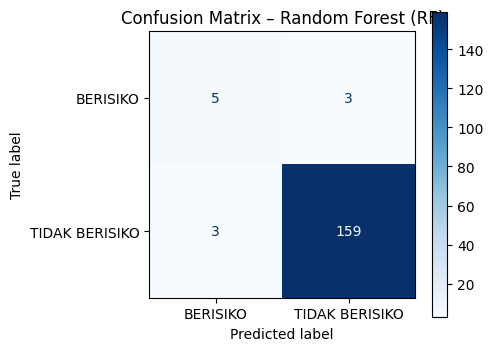


────────────────────────────────────────────────────────────
  Tuning: SVM
────────────────────────────────────────────────────────────
Fitting 5 folds for each of 24 candidates, totalling 120 fits

  Best CV F1-Macro   : 0.6375
  Best Params        : {'clf__C': 1, 'clf__class_weight': None, 'clf__gamma': 'auto', 'clf__kernel': 'rbf'}
  Test Accuracy      : 0.8941
  Test F1 (Macro)    : 0.6497
  Test F1 (Weighted) : 0.9148
  ROC-AUC            : 0.1335
  Waktu Tuning       : 18.1 detik

[Classification Report – SVM]
                precision    recall  f1-score   support

      BERISIKO       0.25      0.62      0.36         8
TIDAK BERISIKO       0.98      0.91      0.94       162

      accuracy                           0.89       170
     macro avg       0.61      0.77      0.65       170
  weighted avg       0.95      0.89      0.91       170



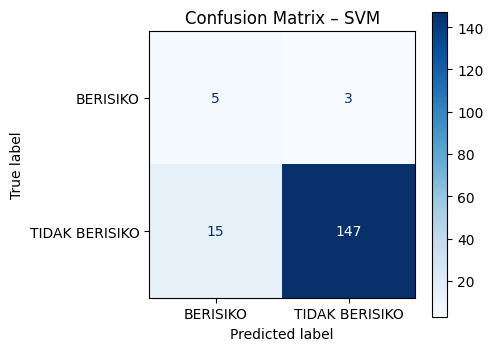


────────────────────────────────────────────────────────────
  Tuning: XGBoost
────────────────────────────────────────────────────────────
Fitting 5 folds for each of 72 candidates, totalling 360 fits

  Best CV F1-Macro   : 0.7433
  Best Params        : {'clf__learning_rate': 0.05, 'clf__max_depth': 6, 'clf__n_estimators': 100, 'clf__scale_pos_weight': 19, 'clf__subsample': 0.8}
  Test Accuracy      : 0.9588
  Test F1 (Macro)    : 0.7833
  Test F1 (Weighted) : 0.9600
  ROC-AUC            : 0.1134
  Waktu Tuning       : 122.0 detik

[Classification Report – XGBoost]
                precision    recall  f1-score   support

      BERISIKO       0.56      0.62      0.59         8
TIDAK BERISIKO       0.98      0.98      0.98       162

      accuracy                           0.96       170
     macro avg       0.77      0.80      0.78       170
  weighted avg       0.96      0.96      0.96       170



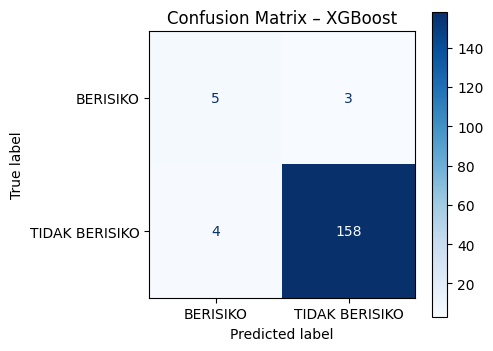


────────────────────────────────────────────────────────────
  Tuning: LightGBM
────────────────────────────────────────────────────────────
Fitting 5 folds for each of 32 candidates, totalling 160 fits

  Best CV F1-Macro   : 0.6859
  Best Params        : {'clf__class_weight': None, 'clf__learning_rate': 0.05, 'clf__n_estimators': 100, 'clf__num_leaves': 31, 'clf__subsample': 0.8}
  Test Accuracy      : 0.9529
  Test F1 (Macro)    : 0.7654
  Test F1 (Weighted) : 0.9554
  ROC-AUC            : 0.1026
  Waktu Tuning       : 256.4 detik

[Classification Report – LightGBM]
                precision    recall  f1-score   support

      BERISIKO       0.50      0.62      0.56         8
TIDAK BERISIKO       0.98      0.97      0.98       162

      accuracy                           0.95       170
     macro avg       0.74      0.80      0.77       170
  weighted avg       0.96      0.95      0.96       170



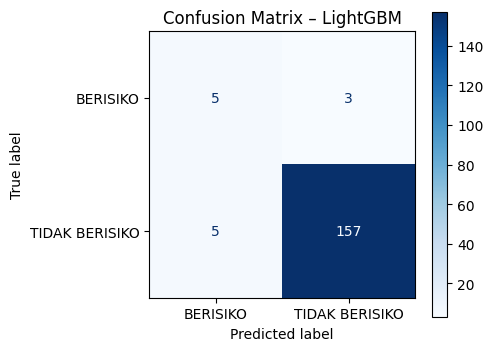

In [ ]:
print("\n[4/9] Menghitung Logika Multiplier untuk Data Berisiko (SMOTE)...")

label_risk = le.transform(['BERISIKO'])[0]
label_safe = le.transform(['TIDAK BERISIKO'])[0]

count_safe = int((y_train == label_safe).sum())
count_risk = int((y_train == label_risk).sum())

multiplier        = count_safe // count_risk
target_risk_count = count_risk * multiplier
sampling_dict     = {label_safe: count_safe, label_risk: target_risk_count}

print(f" -> Data Mayoritas (TIDAK BERISIKO) : {count_safe}")
print(f" -> Data Minoritas (BERISIKO)       : {count_risk}")
print(f" -> Pengali Ditemukan (Multiplier)  : {multiplier}x")
print(f" -> Target Data Berisiko Baru (SMOTE): {target_risk_count}")

def make_smote():
    """Factory SMOTE agar setiap pipeline mendapat instance baru."""
    return SMOTE(sampling_strategy=sampling_dict, random_state=42)


#GRIDSEARCH – 4 ALGORITMA

print("\n" + "="*80)
print("[5/9] GRIDSEARCH HYPERPARAMETER TUNING – 4 ALGORITMA (Balancing: SMOTE)")
print("="*80)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
algo_configs = {
    "Random Forest (RF)": {
        "estimator":    RandomForestClassifier(random_state=42, n_jobs=-1),
        "param_grid":   {
            "clf__n_estimators":    [100, 200],
            "clf__max_depth":       [None, 10, 20],
            "clf__min_samples_split": [2, 5],
            "clf__class_weight":    ["balanced", None]
        },
        "needs_scaling": False
    },
    "SVM": {
        "estimator":    SVC(probability=True, random_state=42),
        "param_grid":   {
            "clf__C":            [0.1, 1, 10],
            "clf__kernel":       ["rbf", "linear"],
            "clf__gamma":        ["scale", "auto"],
            "clf__class_weight": ["balanced", None]
        },
        "needs_scaling": True
    },
    "XGBoost": {
        "estimator":    XGBClassifier(eval_metric='logloss', use_label_encoder=False,
                                      random_state=42, n_jobs=-1),
        "param_grid":   {
            "clf__n_estimators":     [100, 200],
            "clf__max_depth":        [3, 6, 9],
            "clf__learning_rate":    [0.05, 0.1, 0.2],
            "clf__subsample":        [0.8, 1.0],
            "clf__scale_pos_weight": [1, count_safe // count_risk]
        },
        "needs_scaling": False
    },
    "LightGBM": {
        "estimator":    LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        "param_grid":   {
            "clf__n_estimators":  [100, 200],
            "clf__num_leaves":    [31, 63],
            "clf__learning_rate": [0.05, 0.1],
            "clf__subsample":     [0.8, 1.0],
            "clf__class_weight":  ["balanced", None]
        },
        "needs_scaling": False
    }
}

best_results   = {}
gridsearch_log = []

for algo_name, config in algo_configs.items():
    print(f"\n{'─'*60}")
    print(f"  Tuning: {algo_name}")
    print(f"{'─'*60}")

    estimator     = config["estimator"]
    param_grid    = config["param_grid"]
    needs_scaling = config["needs_scaling"]

    if needs_scaling:
        pipe = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote',  make_smote()),
            ('clf',    estimator)
        ])
    else:
        pipe = ImbPipeline([
            ('smote', make_smote()),
            ('clf',   estimator)
        ])

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    t0 = time()
    gs.fit(X_train_df, y_train)
    elapsed = time() - t0

    best_pipe     = gs.best_estimator_
    best_params   = gs.best_params_
    best_cv_score = gs.best_score_

    y_pred      = best_pipe.predict(X_test_df)
    acc         = accuracy_score(y_test, y_pred)
    f1_macro    = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    try:
        y_proba = best_pipe.predict_proba(X_test_df)[:, label_risk]
        roc     = roc_auc_score(y_test, y_proba)
    except Exception:
        roc = np.nan

    print(f"\n  Best CV F1-Macro   : {best_cv_score:.4f}")
    print(f"  Best Params        : {best_params}")
    print(f"  Test Accuracy      : {acc:.4f}")
    print(f"  Test F1 (Macro)    : {f1_macro:.4f}")
    print(f"  Test F1 (Weighted) : {f1_weighted:.4f}")
    print(f"  ROC-AUC            : {roc:.4f}" if not np.isnan(roc) else "  ROC-AUC            : N/A")
    print(f"  Waktu Tuning       : {elapsed:.1f} detik")

    print(f"\n[Classification Report – {algo_name}]")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_).plot(cmap='Blues', ax=ax)
    ax.set_title(f"Confusion Matrix – {algo_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,
        f"cm_{algo_name.replace(' ','_').replace('(','').replace(')','')}.png"), dpi=120)
    plt.show()

    best_results[algo_name] = {
        "pipeline":    best_pipe,
        "best_params": best_params,
        "cv_f1":       best_cv_score,
        "acc":         acc,
        "f1_macro":    f1_macro,
        "f1_weighted": f1_weighted,
        "roc_auc":     roc,
        "y_pred":      y_pred,
        "time":        elapsed
    }

    gridsearch_log.append({
        "Algoritma":        algo_name,
        "Best CV F1-Macro": round(best_cv_score, 4),
        "Test Accuracy":    round(acc, 4),
        "Test F1-Macro":    round(f1_macro, 4),
        "Test F1-Weighted": round(f1_weighted, 4),
        "ROC-AUC":          round(roc, 4) if not np.isnan(roc) else "N/A",
        "Waktu (detik)":    round(elapsed, 1)
    })



SUMMARY PERBANDINGAN 4 ALGORITMA (SETELAH GRIDSEARCH + SMOTE)
         Algoritma  Best CV F1-Macro  Test Accuracy  Test F1-Macro  Test F1-Weighted  ROC-AUC  Waktu (detik)
Random Forest (RF)            0.6901         0.9647         0.8032            0.9647   0.0714           70.7
           XGBoost            0.7433         0.9588         0.7833            0.9600   0.1134          122.0
          LightGBM            0.6859         0.9529         0.7654            0.9554   0.1026          256.4
               SVM            0.6375         0.8941         0.6497            0.9148   0.1335           18.1

🏆 MODEL TERBAIK: Random Forest (RF)
   F1-Macro  : 0.8032
   Accuracy  : 0.9647
   ROC-AUC   : 0.0714


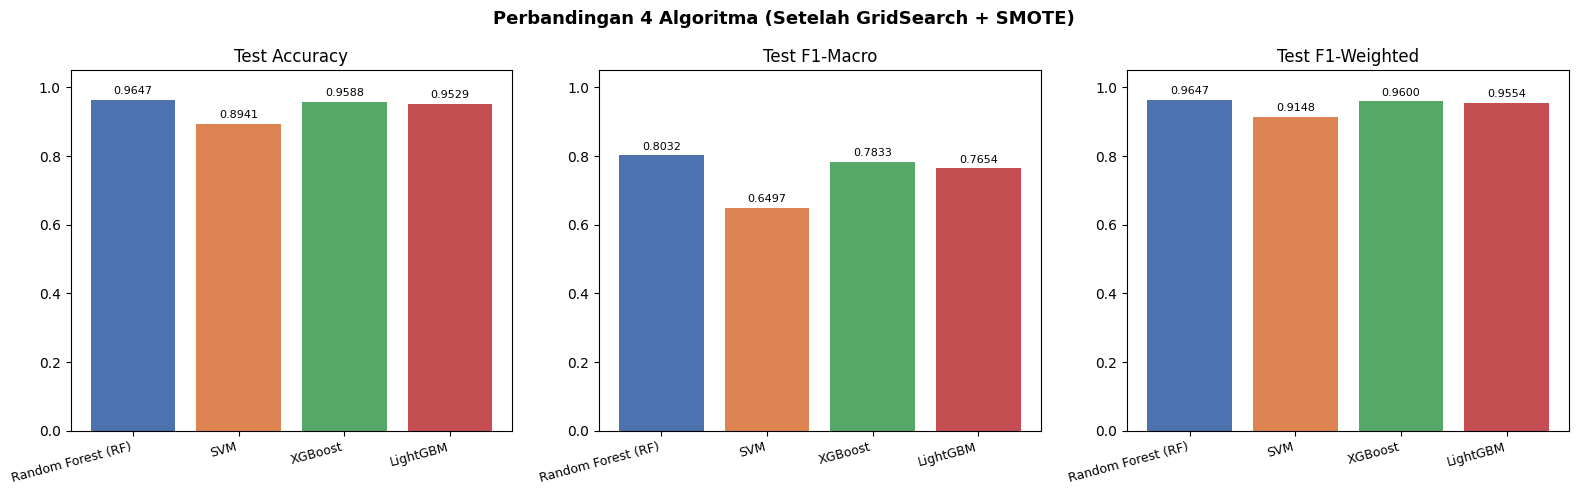


[7/9] STUDI ABLASI PER FITUR – MODEL TERBAIK: Random Forest (RF)
      Total Fitur: 41 (tanpa TAHUN & NAMA SKPD)

  [PRE-PROCESS ABLASI] Menerapkan SMOTE sekali pada training data (41 fitur)...
  Distribusi setelah SMOTE : TIDAK BERISIKO = 377 | BERISIKO = 361

  [BASELINE] Melatih dengan SEMUA 41 fitur (data sudah di-SMOTE)...
  Baseline – F1-Macro: 0.8032  |  Accuracy: 0.9647

  Leave-One-Feature-Out Ablation (41 iterasi)...
  Fitur Dihapus                            Fitur Sisa   F1-Macro   Accuracy   Delta F1
  ──────────────────────────────────────── ────────── ────────── ────────── ──────────
  PAGU POKOK                                       40     0.8256     0.9706    +0.0224  🟢 Dapat Dihapus
  PAGU PARSIAL                                     40     0.8256     0.9706    +0.0224  🟢 Dapat Dihapus
  PAGU PERUBAHAN                                   40     0.8256     0.9706    +0.0224  🟢 Dapat Dihapus
  TARGET FISIK TW1                                 40     0.7833     0.9588    -0.

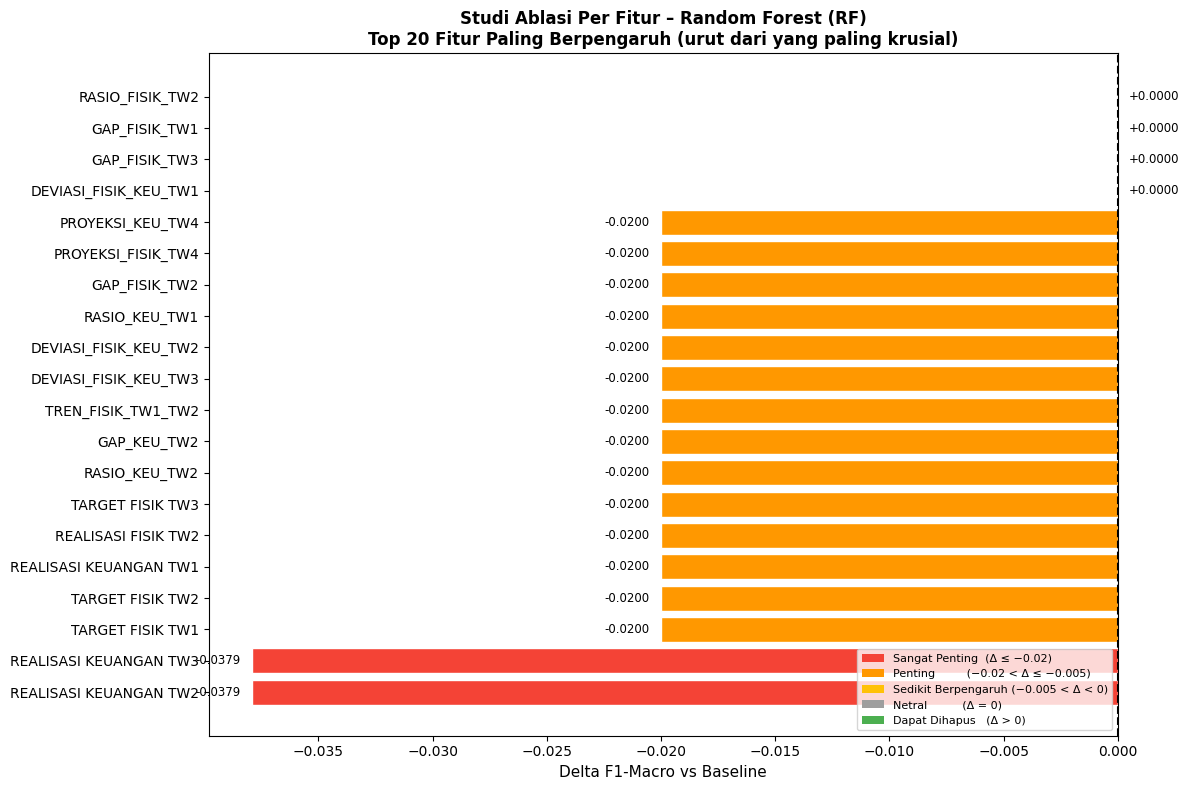


[8/9] MENYIMPAN MODEL TERBAIK KE FILE PKL: Random Forest (RF)
  ✅ Model berhasil disimpan: output_models/best_model_Random_Forest_RF.pkl
     - Algoritma         : Random Forest (RF)
     - Balancing         : SMOTE (multiplier 19x)
     - Jumlah Fitur      : 41 (tanpa TAHUN & NAMA SKPD)
     - Best Params       : {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 100}

  [VERIFIKASI] Memuat ulang model dari PKL...
  ✅ Verifikasi berhasil – F1-Macro dari PKL: 0.8032

[9/9] SUMMARY AKHIR LENGKAP

--- Perbandingan 4 Algoritma (setelah GridSearch + ROS) ---
         Algoritma  Best CV F1-Macro  Test Accuracy  Test F1-Macro  Test F1-Weighted  ROC-AUC  Waktu (detik)
Random Forest (RF)            0.6901         0.9647         0.8032            0.9647   0.0714           70.7
           XGBoost            0.7433         0.9588         0.7833            0.9600   0.1134          122.0
          LightGBM            0.6859         0.9529   

In [ ]:
#SUMMARY PERBANDINGAN 4 ALGORITMA

print("\n" + "="*80)
print("SUMMARY PERBANDINGAN 4 ALGORITMA (SETELAH GRIDSEARCH + SMOTE)")
print("="*80)
summary_df = pd.DataFrame(gridsearch_log).sort_values(by='Test F1-Macro', ascending=False)
print(summary_df.to_string(index=False))

# Tentukan model terbaik
best_algo_name = max(best_results, key=lambda k: best_results[k]['f1_macro'])
best_algo_info = best_results[best_algo_name]
print(f"\n🏆 MODEL TERBAIK: {best_algo_name}")
print(f"   F1-Macro  : {best_algo_info['f1_macro']:.4f}")
print(f"   Accuracy  : {best_algo_info['acc']:.4f}")
print(f"   ROC-AUC   : {best_algo_info['roc_auc']:.4f}" if not np.isnan(best_algo_info['roc_auc']) else "   ROC-AUC   : N/A")

# Visualisasi perbandingan 4 algoritma
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Perbandingan 4 Algoritma (Setelah GridSearch + SMOTE)', fontsize=13, fontweight='bold')
metrics      = ['Test Accuracy', 'Test F1-Macro', 'Test F1-Weighted']
bar_colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
algo_names   = [r['Algoritma'] for r in gridsearch_log]

for i, metric in enumerate(metrics):
    vals = [r[metric] if isinstance(r[metric], float) else 0.0 for r in gridsearch_log]
    bars = axes[i].bar(algo_names, vals, color=bar_colors)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1.05)
    axes[i].set_xticklabels(algo_names, rotation=15, ha='right', fontsize=9)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                     f"{val:.4f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "perbandingan_4_algoritma.png"), dpi=120)
plt.show()

# STUDI ABLASI PER FITUR – MODEL TERBAIK

print("\n" + "="*80)
print(f"[7/9] STUDI ABLASI PER FITUR – MODEL TERBAIK: {best_algo_name}")
print(f"      Total Fitur: {len(ENCODED_FEATURES)} (tanpa TAHUN & NAMA SKPD)")
print("="*80)
best_params_raw = {k.replace('clf__', ''): v for k, v in best_algo_info['best_params'].items()}

def make_bare_estimator(algo_name, params):
    """Buat estimator tanpa pipeline (ROS sudah diterapkan di luar)."""
    if algo_name == "Random Forest (RF)":
        return RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    elif algo_name == "SVM":
        return SVC(**params, probability=True, random_state=42)
    elif algo_name == "XGBoost":
        return XGBClassifier(**params, eval_metric='logloss',
                             use_label_encoder=False, random_state=42, n_jobs=-1)
    elif algo_name == "LightGBM":
        return LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)

needs_scaling_best = algo_configs[best_algo_name]["needs_scaling"]
print("\n  [PRE-PROCESS ABLASI] Menerapkan SMOTE sekali pada training data (41 fitur)...")
smote_ablasi = make_smote()
X_train_arr = X_train_df.values
X_train_res, y_train_res = smote_ablasi.fit_resample(X_train_arr, y_train)
X_train_res_df = pd.DataFrame(X_train_res, columns=ENCODED_FEATURES)

count_res_safe = int((y_train_res == label_safe).sum())
count_res_risk = int((y_train_res == label_risk).sum())
print(f"  Distribusi setelah SMOTE : TIDAK BERISIKO = {count_res_safe} | BERISIKO = {count_res_risk}")

if needs_scaling_best:
    scaler_ablasi = StandardScaler()
    X_train_res_scaled = scaler_ablasi.fit_transform(X_train_res_df)
    X_train_res_df_sc  = pd.DataFrame(X_train_res_scaled, columns=ENCODED_FEATURES)
    X_test_sc          = pd.DataFrame(scaler_ablasi.transform(X_test_df), columns=ENCODED_FEATURES)
else:
    X_train_res_df_sc = X_train_res_df
    X_test_sc         = X_test_df.copy()
print("\n  [BASELINE] Melatih dengan SEMUA 41 fitur (data sudah di-SMOTE)...")
clf_base = make_bare_estimator(best_algo_name, best_params_raw)
clf_base.fit(X_train_res_df_sc[ENCODED_FEATURES], y_train_res)
y_pred_base  = clf_base.predict(X_test_sc[ENCODED_FEATURES])
baseline_f1  = f1_score(y_test, y_pred_base, average='macro')
baseline_acc = accuracy_score(y_test, y_pred_base)
print(f"  Baseline – F1-Macro: {baseline_f1:.4f}  |  Accuracy: {baseline_acc:.4f}")
print(f"\n  Leave-One-Feature-Out Ablation ({len(ENCODED_FEATURES)} iterasi)...")
print(f"  {'Fitur Dihapus':<40} {'Fitur Sisa':>10} {'F1-Macro':>10} {'Accuracy':>10} {'Delta F1':>10}")
print(f"  {'─'*40} {'─'*10} {'─'*10} {'─'*10} {'─'*10}")

ablation_records = [{
    "Fitur Dihapus":     "BASELINE (Semua Fitur)",
    "Jumlah Fitur Sisa": len(ENCODED_FEATURES),
    "F1-Macro":          round(baseline_f1, 4),
    "Accuracy":          round(baseline_acc, 4),
    "Delta F1 vs Base":  0.0,
    "Dampak":            "–"
}]

for feat in ENCODED_FEATURES:
    remaining = [f for f in ENCODED_FEATURES if f != feat]

    X_tr_abl = X_train_res_df_sc[remaining]
    X_te_abl = X_test_sc[remaining]

    clf_abl = make_bare_estimator(best_algo_name, best_params_raw)
    clf_abl.fit(X_tr_abl, y_train_res)
    y_pred_abl = clf_abl.predict(X_te_abl)

    abl_f1  = f1_score(y_test, y_pred_abl, average='macro')
    abl_acc = accuracy_score(y_test, y_pred_abl)
    delta   = abl_f1 - baseline_f1

    if delta <= -0.02:
        dampak = "🔴 Sangat Penting"
    elif delta <= -0.005:
        dampak = "🟠 Penting"
    elif delta < 0:
        dampak = "🟡 Sedikit Berpengaruh"
    elif delta == 0:
        dampak = "⚪ Netral"
    else:
        dampak = "🟢 Dapat Dihapus"

    print(f"  {feat:<40} {len(remaining):>10} {abl_f1:>10.4f} {abl_acc:>10.4f} {delta:>+10.4f}  {dampak}")

    ablation_records.append({
        "Fitur Dihapus":     feat,
        "Jumlah Fitur Sisa": len(remaining),
        "F1-Macro":          round(abl_f1, 4),
        "Accuracy":          round(abl_acc, 4),
        "Delta F1 vs Base":  round(delta, 4),
        "Dampak":            dampak
    })

ablation_df = pd.DataFrame(ablation_records)
ablation_sorted = ablation_df[ablation_df['Fitur Dihapus'] != "BASELINE (Semua Fitur)"] \
                    .sort_values(by='Delta F1 vs Base')

print("\n" + "="*80)
print("RANKING FITUR PALING BERPENGARUH (Delta F1 terkecil = paling penting)")
print("="*80)
print(ablation_sorted[['Fitur Dihapus', 'F1-Macro', 'Accuracy', 'Delta F1 vs Base', 'Dampak']] \
      .reset_index(drop=True).to_string(index=True))

ablation_csv_path = os.path.join(OUTPUT_DIR, "ablation_per_fitur.csv")
ablation_df.to_csv(ablation_csv_path, index=False)
print(f"\n  Tabel ablasi disimpan: {ablation_csv_path}")
top_n       = min(20, len(ablation_sorted))
top_ablation = ablation_sorted.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
bar_colors_abl = ['#F44336' if d < -0.02
                  else '#FF9800' if d < -0.005
                  else '#FFC107' if d < 0
                  else '#9E9E9E' if d == 0
                  else '#4CAF50'
                  for d in top_ablation['Delta F1 vs Base']]

bars = ax.barh(top_ablation['Fitur Dihapus'], top_ablation['Delta F1 vs Base'],
               color=bar_colors_abl, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_xlabel('Delta F1-Macro vs Baseline', fontsize=11)
ax.set_title(f'Studi Ablasi Per Fitur – {best_algo_name}\n'
             f'Top {top_n} Fitur Paling Berpengaruh (urut dari yang paling krusial)',
             fontsize=12, fontweight='bold')


for bar, val in zip(bars, top_ablation['Delta F1 vs Base']):
    xpos = val - 0.0005 if val < 0 else val + 0.0005
    ha   = 'right' if val < 0 else 'left'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f"{val:+.4f}", va='center', ha=ha, fontsize=8.5)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F44336', label='Sangat Penting  (Δ ≤ −0.02)'),
    Patch(facecolor='#FF9800', label='Penting         (−0.02 < Δ ≤ −0.005)'),
    Patch(facecolor='#FFC107', label='Sedikit Berpengaruh (−0.005 < Δ < 0)'),
    Patch(facecolor='#9E9E9E', label='Netral          (Δ = 0)'),
    Patch(facecolor='#4CAF50', label='Dapat Dihapus   (Δ > 0)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "ablation_per_fitur_top20.png"), dpi=120)
plt.show()


print("\n" + "="*80)
print(f"[8/9] MENYIMPAN MODEL TERBAIK KE FILE PKL: {best_algo_name}")
print("="*80)

model_artifacts = {
    "pipeline":      best_algo_info['pipeline'],
    "label_encoder": le,
    "feature_names": ENCODED_FEATURES,
    "best_params":   best_algo_info['best_params'],
    "algo_name":     best_algo_name,
    "balancing":     "SMOTE",
    "metrics": {
        "accuracy":    best_algo_info['acc'],
        "f1_macro":    best_algo_info['f1_macro'],
        "f1_weighted": best_algo_info['f1_weighted'],
        "roc_auc":     best_algo_info['roc_auc']
    }
}

safe_name = best_algo_name.replace(' ','_').replace('(','').replace(')','')
pkl_path  = os.path.join(OUTPUT_DIR, f"best_model_{safe_name}.pkl")
joblib.dump(model_artifacts, pkl_path)
print(f"  ✅ Model berhasil disimpan: {pkl_path}")
print(f"     - Algoritma         : {best_algo_name}")
print(f"     - Balancing         : SMOTE (multiplier {multiplier}x)")
print(f"     - Jumlah Fitur      : {len(ENCODED_FEATURES)} (tanpa TAHUN & NAMA SKPD)")
print(f"     - Best Params       : {best_algo_info['best_params']}")

# Verifikasi Load PKL
print("\n  [VERIFIKASI] Memuat ulang model dari PKL...")
loaded      = joblib.load(pkl_path)
pipe_loaded = loaded['pipeline']
y_verify    = pipe_loaded.predict(X_test_df)
verify_f1   = f1_score(y_test, y_verify, average='macro')
print(f"  ✅ Verifikasi berhasil – F1-Macro dari PKL: {verify_f1:.4f}")


print("\n" + "="*80)
print("[9/9] SUMMARY AKHIR LENGKAP")
print("="*80)

print("\n--- Perbandingan 4 Algoritma (setelah GridSearch + ROS) ---")
print(summary_df.to_string(index=False))

print(f"\n--- Model Terbaik: {best_algo_name} ---")
print(f"  Best Params  : {best_algo_info['best_params']}")
print(f"  F1-Macro     : {best_algo_info['f1_macro']:.4f}")
print(f"  Accuracy     : {best_algo_info['acc']:.4f}")
print(f"  ROC-AUC      : {best_algo_info['roc_auc']:.4f}" if not np.isnan(best_algo_info['roc_auc']) else "  ROC-AUC      : N/A")

print(f"\n--- Top 10 Fitur Paling Penting (dari Studi Ablasi) ---")
print(ablation_sorted[['Fitur Dihapus', 'F1-Macro', 'Delta F1 vs Base', 'Dampak']] \
      .head(10).reset_index(drop=True).to_string(index=True))

print(f"\n--- File Output (folder: {OUTPUT_DIR}/) ---")
print(f"  Model PKL          : {pkl_path}")
print(f"  Ablasi CSV         : {ablation_csv_path}")
print(f"  Grafik ablasi      : ablation_per_fitur_top20.png")
print(f"  Heatmap ablasi     : ablation_heatmap_semua_fitur.png")
print(f"  Perbandingan algo  : perbandingan_4_algoritma.png")

print("\n✅ SELESAI.")